### Importación de Librerías

In [25]:
import os
import numpy as np
from astropy.io import fits
from astropy.nddata import CCDData
import ccdproc
from astropy import units as u
from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift
from collections import defaultdict
from astropy.visualization import ZScaleInterval
import matplotlib.pyplot as plt
from PIL import Image 
from image_registration import chi2_shift
from image_registration.fft_tools import shift as img_shift
from scipy.signal import fftconvolve

### Reducción, Stacking y Alineamiento de Imágenes

In [29]:
import os
import numpy as np
from astropy.io import fits
from skimage.registration import phase_cross_correlation
from scipy.ndimage import shift

# Base route
#Procesando las imágenes de NGC 1365 para 3I/ATLAS, descomentar la otra línea, y viceversa
#object = "NGC_1365"
object = "3I_ATLAS"
base_path = f"../{object}/"

# Outputs
master_dir = os.path.join(base_path, "Camila/Master/")
aligned_dir = os.path.join(base_path, "Camila/Aligned/")
summed_dir = os.path.join(base_path, "Camila/Summed/")
aligned_summed_dir = os.path.join(base_path, "Camila/Aligned_Summed/")
os.makedirs(master_dir, exist_ok=True)
os.makedirs(aligned_dir, exist_ok=True)
os.makedirs(summed_dir, exist_ok=True)
os.makedirs(aligned_summed_dir, exist_ok=True)

# Función recursiva para encontrar archivos FITS en subcarpetas
def get_fits_files(folder_path, prefix=""):
    files = []
    if not os.path.exists(folder_path):
        return []
    for root, dirs, filenames in os.walk(folder_path):
        for f in filenames:
            if f.lower().startswith(prefix.lower()) and f.lower().endswith(('.fits', '.fit')):
                files.append(os.path.join(root, f))
    return sorted(files)

# CARGA DE ARCHIVOS 
print("Cargando archivos...")

bias_files = get_fits_files(os.path.join(base_path, "Bias"), "bias")
dark_files = get_fits_files(os.path.join(base_path, "Dark"), "dark")
flat_files_clear = get_fits_files(os.path.join(base_path, "Flat", "clear"), "flat")
flat_files_i = get_fits_files(os.path.join(base_path, "Flat", "i"), "flat")
flat_files_g = get_fits_files(os.path.join(base_path, "Flat", "g"), "flat")
flat_files_r = get_fits_files(os.path.join(base_path, "Flat", "r"), "flat")

light_files_clear = get_fits_files(os.path.join(base_path, "Light", "clear"), f"{object.replace("_", "")}")
light_files_i = get_fits_files(os.path.join(base_path, "Light", "i"), f"{object.replace("_", "")}")
light_files_g = get_fits_files(os.path.join(base_path, "Light", "g"), f"{object.replace("_", "")}")
light_files_r = get_fits_files(os.path.join(base_path, "Light", "r"), f"{object.replace("_", "")}")

if not bias_files: raise ValueError("No se encontraron archivos Bias.")
if not dark_files: raise ValueError("No se encontraron archivos Dark.")
if not light_files_clear: raise ValueError("No se encontraron archivos Light para el filtro Clear.")
if not light_files_i: raise ValueError("No se encontraron archivos Light para el filtro i'.")
if not light_files_g: raise ValueError("No se encontraron archivos Light para el filtro g'.")
if not light_files_r: raise ValueError("No se encontraron archivos Light para el filtro r'.")

light_by_filter = {
    "clear": light_files_clear,
    "i": light_files_i,
    "g": light_files_g,
    "r": light_files_r
}

# FUNCIONES DE PROCESAMIENTO

def combine_images_median(file_list):
    """Para Bias y Flats usamos MEDIAN (menos artefactos)."""
    data_stack = []
    for f in file_list:
        try:
            data = fits.getdata(f).astype(float)
            data_stack.append(data)
        except Exception as e:
            print(f"Error al leer {f}: {str(e)}")
            continue
    if not data_stack: raise ValueError("No images to combine")
    return np.median(data_stack, axis=0)

# CREACIÓN DE MASTERS 

# A. Master Bias
print("Creando Master Bias...")
master_bias = combine_images_median(bias_files)
fits.writeto(os.path.join(master_dir, "master_bias.fits"), master_bias, overwrite=True)

# B. Master Dark 
print("Creando Master Dark...")
if dark_files:
    master_dark = combine_images_median(dark_files) 
    fits.writeto(os.path.join(master_dir, "master_dark.fits"), master_dark, overwrite=True)
else:
    master_dark = np.zeros_like(master_bias)

# C. Master Flats (Normalización Individual)
master_flats = {}
flat_config = [
    ("clear", flat_files_clear, master_bias),
    ("i", flat_files_i, master_bias),
    ("g", flat_files_g, master_bias),
    ("r", flat_files_r, master_bias)
]

print("Creando Master Flats (Estrategia: Normalización Individual)...")
for filt, files, master_bias in flat_config:
    if not files:
        print(f"Warning: No flats found for filter {filt}")
        continue
    try:
        normalized_stack = []
        for f in files:
            data = fits.getdata(f).astype(float)
            corrected = data - master_bias
            median_val = np.median(corrected)
            normalized_frame = corrected / median_val
            normalized_stack.append(normalized_frame)
        
        master_flat_final = np.median(normalized_stack, axis=0)
        master_flats[filt] = master_flat_final
        fits.writeto(os.path.join(master_dir, f"master_flat_{filt}.fits"), master_flat_final, overwrite=True)
        print(f"Master Flat {filt} creado correctamente.")
    except Exception as e:
        print(f"Error processing flats for filter {filt}: {str(e)}")

# REDUCCIÓN DE IMÁGENES CIENTÍFICAS

def reduce_light(path, filt):
    try:
        data = fits.getdata(path).astype(float)
        if filt not in master_flats:
            raise ValueError(f"No master flat for filter {filt}")
            
        # 1. Calibración estándar
        reduced = (data - master_dark) / master_flats[filt]
        
        # 2. LIMPIEZA DE PÍXELES NEGATIVOS (Evita agujeros negros)
        median_val = np.nanmedian(reduced)
        bad_pixel_mask = reduced < 0 # Solo corregimos los negativos profundos
        reduced[bad_pixel_mask] = median_val

        return reduced
    except Exception as e:
        print(f"Error reducing {path}: {str(e)}")
        return None

# ALINEACIÓN Y EJECUCIÓN

def enhanced_align_images(image_list, reference_image=None, upsample_factor=10):
    if not image_list: return []
    aligned = []
    
    if reference_image is None:
        ref_image = image_list[0]
        aligned.append(ref_image) 
        images_to_align = image_list[1:]
    else:
        ref_image = reference_image
        images_to_align = image_list 
    
    crop_pixels = 50
    h, w = ref_image.shape
    ref_cropped = ref_image[crop_pixels:h-crop_pixels, crop_pixels:w-crop_pixels]
    
    for img in images_to_align:
        try:
            img_cropped = img[crop_pixels:h-crop_pixels, crop_pixels:w-crop_pixels]
            shift_val, error, diffphase = phase_cross_correlation(
                ref_cropped, img_cropped, upsample_factor=upsample_factor, normalization=None
            )
            shifted = shift(img, shift_val, mode='reflect')
            aligned.append(shifted)
        except Exception as e:
            print(f"Error alineando imagen: {str(e)}")
            aligned.append(img) 
            continue
            
    return aligned

# --- PROCESO PRINCIPAL ---

global_reference_image = None
filters_order = ["r", "i", "g", "clear"]

for filt in filters_order:
    files = light_by_filter.get(filt, [])
    
    if files:
        print(f"\nProcesando filtro {filt} con {len(files)} imágenes...")
        
        reduced_imgs = []
        for f in files:
            reduced = reduce_light(f, filt)
            if reduced is not None: reduced_imgs.append(reduced)
        
        if reduced_imgs:
            if global_reference_image is None:
                print("  > Creando referencia de alineación (Master)...")
                aligned_imgs = enhanced_align_images(reduced_imgs, upsample_factor=20)
                global_reference_image = aligned_imgs[0]
            else:
                print(f"  > Alineando filtro {filt} contra referencia (r)...")
                aligned_imgs = enhanced_align_images(reduced_imgs, reference_image=global_reference_image, upsample_factor=20)
            
            for idx, img in enumerate(aligned_imgs):
                out_name = os.path.join(aligned_dir, f"aligned_{object.replace("_", "")}_{filt}_{idx+1:03d}.fits")
                fits.writeto(out_name, img, overwrite=True)

# STACKING

print("\nGenerando imágenes finales (Stacking)...")
for filt in ["g", "r", "i", "clear"]:
    aligned_files = get_fits_files(aligned_dir, f"aligned_{object.replace("_", "")}_{filt}")
    if aligned_files:
        stack = []
        for f in aligned_files:
            stack.append(fits.getdata(f).astype(float))
        
        # -------------------------------------------------------------
        # CAMBIO CLAVE: Usamos MEDIAN en lugar de MEAN para las luces.
        # Esto elimina los "gusanos blancos" (trazas de hot pixels)
        # y rayos cósmicos que sobrevivieron.
        # -------------------------------------------------------------
        print(f"  > Combinando {len(stack)} imágenes usando MEDIAN para filtro {filt}...")
        summed = np.median(stack, axis=0)
        
        out_path = os.path.join(summed_dir, f"{object.replace("_", "")}_stacked_{filt}.fits")
        fits.writeto(out_path, summed, overwrite=True)
        print(f"Guardado: {out_path}")
    else:
        print(f"No hay imágenes alineadas para filtro {filt}")

print("\nProceso completado.")

# ALINEADO de stacks

def load_stacked_images():
    # Definimos los nombres generados en el paso anterior
    stacked_files = {
        'clear': os.path.join(summed_dir, f"{object.replace("_", "")}_stacked_clear.fits"),
        'g': os.path.join(summed_dir, f"{object.replace("_", "")}_stacked_g.fits"),
        'r': os.path.join(summed_dir, f"{object.replace("_", "")}_stacked_r.fits"),
        'i': os.path.join(summed_dir, f"{object.replace("_", "")}_stacked_i.fits")
    }
    
    images = {}
    for filt, path in stacked_files.items():
        if os.path.exists(path):
            print(f"Loading {filt}: {path}")
            images[filt] = fits.getdata(path).astype(float)
        else:
            print(f"Warning: File not found for filter {filt}: {path}")
    
    if not images:
        raise FileNotFoundError("No stacked images found in Summed directory.")
        
    return images

# Align images using chi2_shift
def align_with_chi2(images):
    # Check if reference 'r' exists, otherwise pick the first available
    ref_filter = 'r'
    if ref_filter not in images:
        ref_filter = list(images.keys())[0]
        print(f"Warning: Reference filter 'r' not found. Using '{ref_filter}' instead.")
    
    reference = images[ref_filter]
    aligned = {ref_filter: reference}
    
    # Parameters for chi2_shift
    noise_level = np.std(reference)  # Estimate of noise level
    upsample_factor = 'auto' 
    
    print(f"\nStarting alignment with chi2_shift (Reference: {ref_filter})...")
    
    # Iterate over all other filters
    for filt, img in images.items():
        if filt == ref_filter:
            continue # Skip reference
            
        print(f"Aligning filter {filt}...")
        try:
            # Calculate shift
            xoff, yoff, exoff, eyoff = chi2_shift(
                reference, img, noise_level,
                return_error=True, upsample_factor=upsample_factor
            )
            
            # Apply shift (-y, -x ordering is typical for numpy array shifts vs image coords)
            aligned[filt] = img_shift.shiftnd(img, (-yoff, -xoff))
            
            print(f"Displacement {filt}: x={xoff:.2f} ± {exoff:.2f}, y={yoff:.2f} ± {eyoff:.2f}")
        except Exception as e:
            print(f"Error aligning {filt}: {e}. Keeping original.")
            aligned[filt] = img
    
    return aligned

# Save aligned images
def save_aligned_images(aligned_images):
    for filt, img in aligned_images.items():
        # Mantenemos convención de nombres clara
        output_filename = f"aligned_{object.replace("_", "")}_stacked_{filt}.fits"
        output_path = os.path.join(aligned_summed_dir, output_filename)
        
        fits.writeto(output_path, img, overwrite=True)
        print(f"Aligned image {filt} saved to: {output_path}")

# Main process
try:
    # Load images
    print("--- Loading Stacked Images ---")
    images = load_stacked_images()
        
    # Align images
    aligned_images = align_with_chi2(images)
        
    # Save results
    print("\n--- Saving Aligned Images ---")
    save_aligned_images(aligned_images)
        
    print("\nAlignment completed successfully.")
except Exception as e:
    print(f"\nCritical Error during the process: {str(e)}")

Cargando archivos...
Creando Master Bias...
Creando Master Dark...
Creando Master Flats (Estrategia: Normalización Individual)...
Master Flat clear creado correctamente.
Master Flat i creado correctamente.
Master Flat g creado correctamente.
Master Flat r creado correctamente.

Procesando filtro r con 16 imágenes...
  > Creando referencia de alineación (Master)...

Procesando filtro i con 16 imágenes...
  > Alineando filtro i contra referencia (r)...

Procesando filtro g con 16 imágenes...
  > Alineando filtro g contra referencia (r)...

Procesando filtro clear con 7 imágenes...
  > Alineando filtro clear contra referencia (r)...

Generando imágenes finales (Stacking)...
  > Combinando 16 imágenes usando MEDIAN para filtro g...
Guardado: ../3I_ATLAS/Camila/Summed/3IATLAS_stacked_g.fits
  > Combinando 16 imágenes usando MEDIAN para filtro r...
Guardado: ../3I_ATLAS/Camila/Summed/3IATLAS_stacked_r.fits
  > Combinando 16 imágenes usando MEDIAN para filtro i...
Guardado: ../3I_ATLAS/Camila

### Verificación de Procesamiento

68301.01842651294
-2419.887356996024
Imagen cargada.
Límites calculados ZScale -> vmin: 78.79, vmax: 117.73


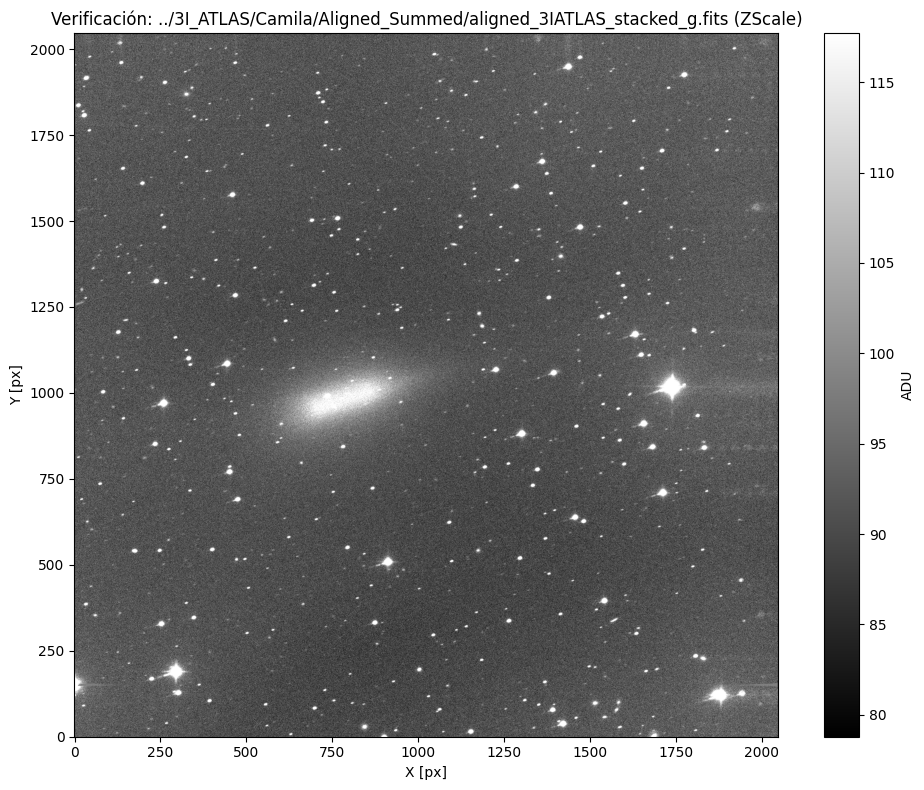

In [30]:
# Base route
#Procesando las imágenes de NGC 1365 para 3I/ATLAS, descomentar la otra línea, y viceversa
#object = "NGC_1365"
object = "3I_ATLAS"
base_path = f"../{object}/"
#Usando el filtro g' para los otros, descomentar la línea respectiva
filter = "g"
#filter = "r"
#filter = "i"
#filter = "clear"
# Outputs
aligned_summed_dir = os.path.join(base_path, "Camila/Aligned_Summed/")
archivo = os.path.join(aligned_summed_dir, f"aligned_{object.replace("_", "")}_stacked_{filter}.fits")

# 1. Cargar
try:
    img = fits.getdata(archivo)
    print(np.max(img))
    print(np.min(img))
    print("Imagen cargada.")
except FileNotFoundError:
    print(f"No encuentro el archivo: {archivo}. Revisa la ruta.")
    img = None

if img is not None:
    # 2. Calcular contraste usando ZScale (El estándar en astronomía)
    # Esto busca el rango de píxeles ignorando las estrellas muy brillantes
    # para enfocarse en la estructura de la galaxia.
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(img)

    print(f"Límites calculados ZScale -> vmin: {vmin:.2f}, vmax: {vmax:.2f}")

    # 3. Graficar
    plt.figure(figsize=(10, 8))
    
    # Usamos los vmin y vmax calculados por ZScale
    plt.imshow(img, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
    
    plt.colorbar(label='ADU')
    plt.title(f"Verificación: {archivo} (ZScale)")
    plt.xlabel("X [px]")
    plt.ylabel("Y [px]")
    plt.tight_layout()
    plt.show()

### Deconvolución

In [31]:
# Base route
#Procesando las imágenes de NGC 1365 para 3I/ATLAS, descomentar la otra línea, y viceversa
#object = "NGC_1365"
object = "3I_ATLAS"
base_path = f"../{object}/"
aligned_summed_dir = os.path.join(base_path, "Camila/Aligned_Summed")
deconv_dir = os.path.join(base_path, "Camila/Deconvolved")
os.makedirs(deconv_dir, exist_ok=True)

# 1. Función para crear una PSF Gaussiana Sintética
# El documento sugiere usar estrellas no saturadas para ajustar una Gaussiana[cite: 40, 41].
# Aquí creamos una PSF teórica promedio.
def make_gaussian_psf(size=21, sigma=2.0):
    """
    Crea una PSF Gaussiana 2D normalizada.
    size: tamaño de la matriz (impar)
    sigma: desviación estándar (ancho del desenfoque en pixeles)
    """
    x = np.linspace(-(size // 2), size // 2, size)
    y = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(x, y)
    
    # Fórmula Gaussiana básica
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    
    # Normalización: La suma de la PSF debe ser 1 [cite: 38]
    return kernel / np.sum(kernel)

# 2. Algoritmo Richardson-Lucy
# Implementación basada en la Diapositiva 2 
def richardson_lucy(image, psf, num_iter=15):
    """
    Aplica deconvolución RL.
    image: Imagen alineada (stacked)
    psf: Point Spread Function estimada
    num_iter: Número de iteraciones (cuidado: muchas iteraciones = más ruido )
    """
    # Copia inicial de la imagen
    im_deconv = image.copy()
    
    # PSF espejada (necesaria para la convolución en el denominador) [cite: 25, 32]
    psf_mirror = np.flip(psf)
    
    eps = 1e-12 # Para evitar división por cero [cite: 33]
    
    print(f"   > Iniciando {num_iter} iteraciones RL...")
    
    for i in range(num_iter):
        # Paso 1: Convolución de la estimación actual con la PSF
        # u_k (conv) PSF 
        conv = fftconvolve(im_deconv, psf, mode='same') + eps
        
        # Paso 2: Corrección multiplicativa
        # u_{k+1} = u_k * ((I / conv) (conv) PSF*) 
        relative_blur = image / conv
        im_deconv *= fftconvolve(relative_blur, psf_mirror, mode='same')
        
    return im_deconv

# --- PROCESO PRINCIPAL ---

def main():
    # Definimos los filtros a procesar
    filtros = ['clear', 'g', 'r', 'i']
    
    # Parámetros de la PSF (Ajustable: Sigma 1.5 a 3.0 suele funcionar bien para telescopios terrestres)
    sigma_psf = 2.0 
    psf = make_gaussian_psf(size=31, sigma=sigma_psf)
    print(f"PSF generada (Sigma={sigma_psf})")

    for filt in filtros:
        input_name = f"aligned_{object.replace("_", "")}_stacked_{filt}.fits"
        input_path = os.path.join(aligned_summed_dir, input_name)
        
        if os.path.exists(input_path):
            print(f"\nProcesando filtro {filt}...")
            
            # Cargar imagen
            data = fits.getdata(input_path).astype(float)
            header = fits.getheader(input_path)
            
            # Limpieza básica previa: RL odia los valores negativos (causan artefactos)
            # Reemplazamos negativos con un valor pequeño positivo o cero
            data[data < 0] = 1e-6
            
            # Ejecutar Deconvolución
            try:
                deconvolved_data = richardson_lucy(data, psf, num_iter=15)
                
                # Guardar resultado
                output_name = f"deconv_{object.replace("_", "")}_{filt}.fits"
                output_path = os.path.join(deconv_dir, output_name)
                
                # Actualizar header para indicar el proceso
                header['PROCESS'] = 'Richardson-Lucy Deconvolution'
                header['RL_ITER'] = 15
                header['RL_SIGMA'] = sigma_psf
                
                fits.writeto(output_path, deconvolved_data, header, overwrite=True)
                print(f"Guardado: {output_path}")
                
            except Exception as e:
                print(f"Error en deconvolución de {filt}: {e}")
        else:
            print(f"No se encontró: {input_path}")

if __name__ == "__main__":
    main()

PSF generada (Sigma=2.0)

Procesando filtro clear...
   > Iniciando 15 iteraciones RL...
Guardado: ../3I_ATLAS/Camila/Deconvolved/deconv_3IATLAS_clear.fits

Procesando filtro g...
   > Iniciando 15 iteraciones RL...
Guardado: ../3I_ATLAS/Camila/Deconvolved/deconv_3IATLAS_g.fits

Procesando filtro r...
   > Iniciando 15 iteraciones RL...
Guardado: ../3I_ATLAS/Camila/Deconvolved/deconv_3IATLAS_r.fits

Procesando filtro i...
   > Iniciando 15 iteraciones RL...
Guardado: ../3I_ATLAS/Camila/Deconvolved/deconv_3IATLAS_i.fits


### Verificación de Deconvolución

276015.2148133898
1.5936722195564865e-09
Imagen cargada.
Límites calculados ZScale -> vmin: 1.90, vmax: 55.15


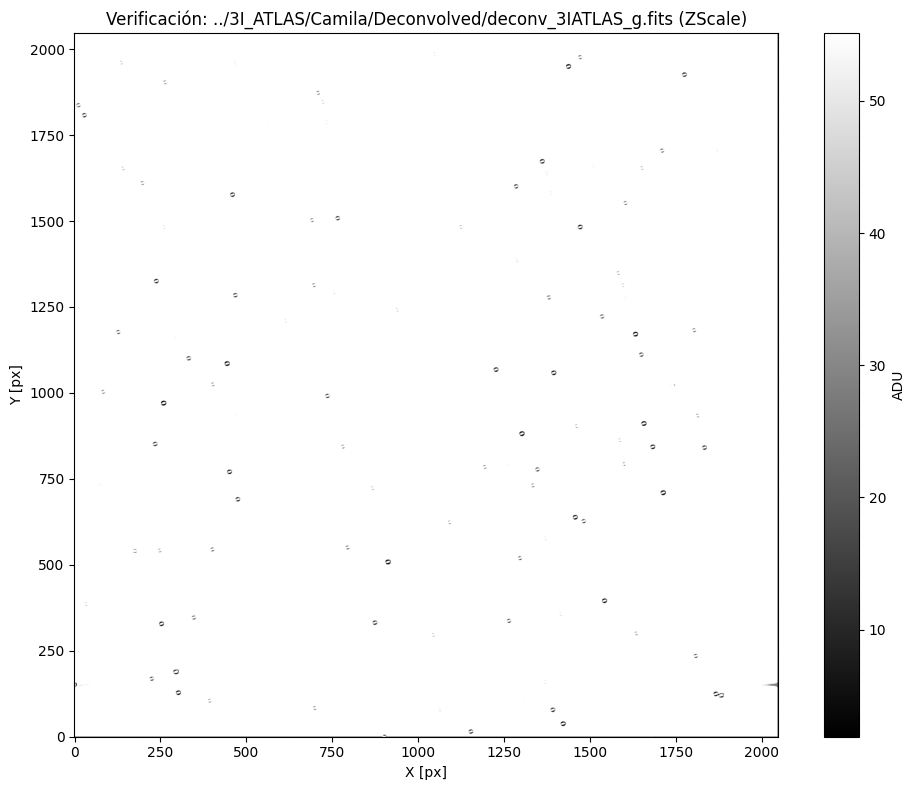

In [32]:
# Base route
#Procesando las imágenes de NGC 1365 para 3I/ATLAS, descomentar la otra línea, y viceversa
#object = "NGC_1365"
object = "3I_ATLAS"
base_path = f"../{object}/"
#Usando el filtro g' para los otros, descomentar la línea respectiva
filter = "g"
#filter = "r"
#filter = "i"
#filter = "clear"
# Outputs
deconv_dir = os.path.join(base_path, "Camila/Deconvolved/")
archivo = os.path.join(deconv_dir, f"deconv_{object.replace("_", "")}_{filter}.fits")

# 1. Cargar
try:
    img = fits.getdata(archivo)
    print(np.max(img))
    print(np.min(img))
    print("Imagen cargada.")
except FileNotFoundError:
    print(f"No encuentro el archivo: {archivo}. Revisa la ruta.")
    img = None

if img is not None:
    # 2. Calcular contraste usando ZScale (El estándar en astronomía)
    # Esto busca el rango de píxeles ignorando las estrellas muy brillantes
    # para enfocarse en la estructura de la galaxia.
    interval = ZScaleInterval()
    vmin, vmax = 1.90, 55.15 

    print(f"Límites calculados ZScale -> vmin: {vmin:.2f}, vmax: {vmax:.2f}")

    # 3. Graficar
    plt.figure(figsize=(10, 8))
    
    # Usamos los vmin y vmax calculados por ZScale
    plt.imshow(img, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
    
    plt.colorbar(label='ADU')
    plt.title(f"Verificación: {archivo} (ZScale)")
    plt.xlabel("X [px]")
    plt.ylabel("Y [px]")
    plt.tight_layout()
    plt.show()

In [33]:
vmin

1.9

In [34]:
vmax

55.15

### Creación de Figura de Imágenes Procesadas (Stack + Alineamiento)

Generando panel de imágenes...


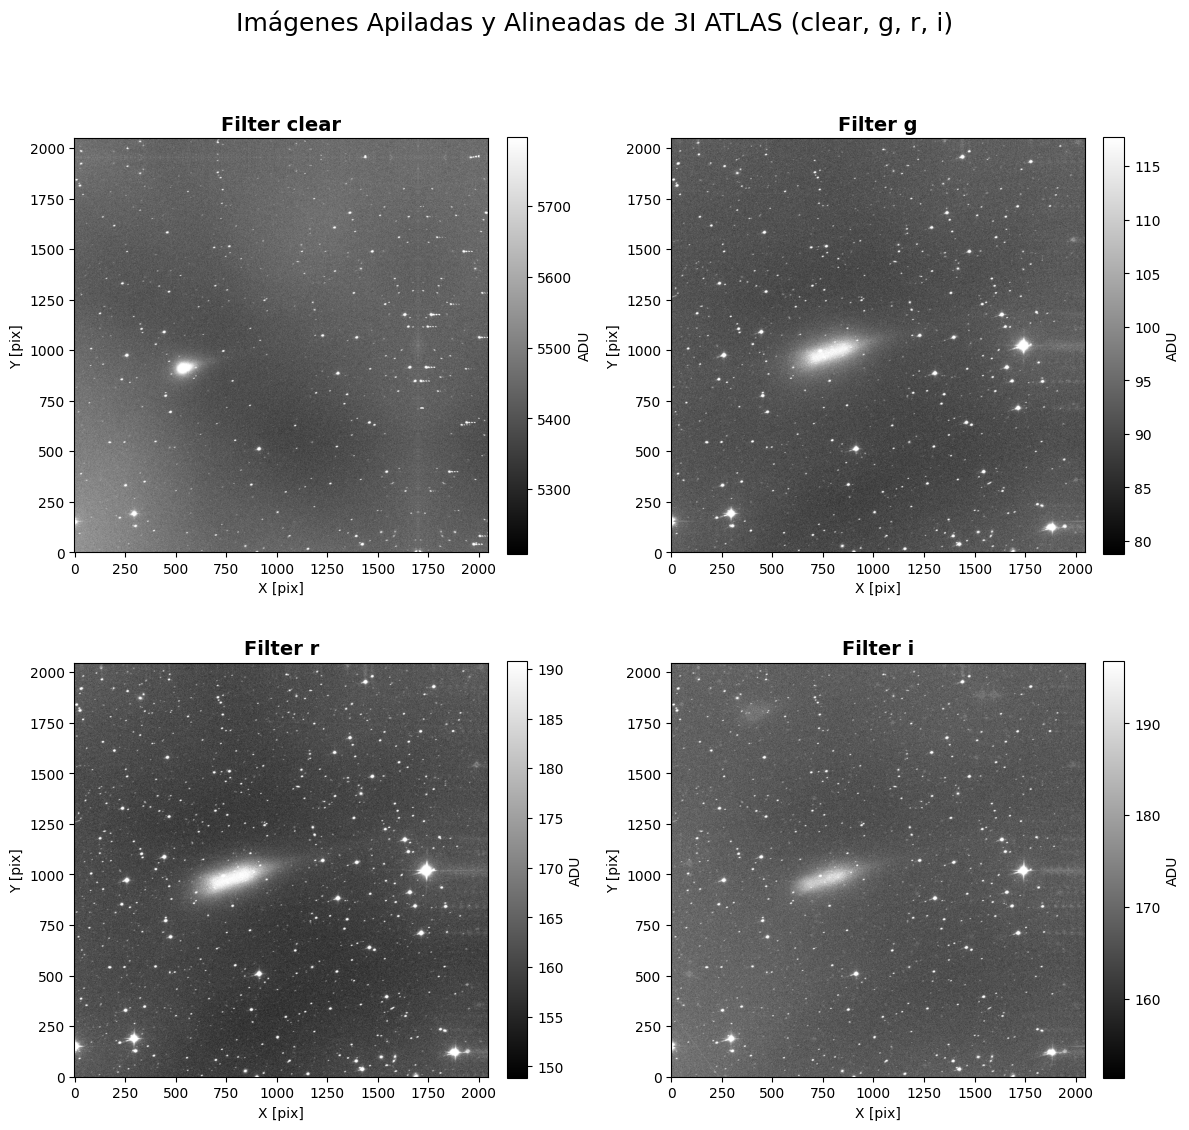

In [35]:
import os
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize

# Base route
#Procesando las imágenes de NGC 1365 para 3I/ATLAS, descomentar la otra línea, y viceversa
#object = "NGC_1365"
object = "3I_ATLAS"
base_path = f"../{object}/"
aligned_summed_dir = os.path.join(base_path, "Camila/Aligned_Summed")

files = {
    'clear': os.path.join(aligned_summed_dir, f"aligned_{object.replace("_", "")}_stacked_clear.fits"),
    'g': os.path.join(aligned_summed_dir, f"aligned_{object.replace("_", "")}_stacked_g.fits"),
    'r': os.path.join(aligned_summed_dir, f"aligned_{object.replace("_", "")}_stacked_r.fits"),
    'i': os.path.join(aligned_summed_dir, f"aligned_{object.replace("_", "")}_stacked_i.fits")
}

# Configuración del gráfico
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
filtros = ['clear', 'g', 'r', 'i']
axes_flat = axes.flatten()

print("Generando panel de imágenes...")

for idx, filt in enumerate(filtros):
    ax = axes_flat[idx]
    filepath = files[filt]
    
    if os.path.exists(filepath):
        try:
            # 1. Cargar datos
            data = fits.getdata(filepath).astype(float)
            
            # 2. Calcular normalización ZScale (Contraste automático astronómico)
            interval = ZScaleInterval()
            vmin, vmax = interval.get_limits(data)
            
            # 3. Graficar
            im = ax.imshow(data, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
            
            # Decoración
            ax.set_title(f"Filter {filt}", fontsize=14, fontweight='bold')
            ax.set_xlabel("X [pix]")
            ax.set_ylabel("Y [pix]")
            
            # Añadir barra de color pequeña
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='ADU')
            
        except Exception as e:
            print(f"Error al leer {filt}: {e}")
            ax.text(0.5, 0.5, f"Error\n{filt}", ha='center', va='center', color='red')
    else:
        ax.text(0.5, 0.5, f"Archivo no encontrado:\n{filt}", ha='center', va='center', color='red')
        print(f"No encontrado: {filepath}")

# Título general
plt.suptitle(f"Imágenes Apiladas y Alineadas de {object.replace("_", " ")} (clear, g, r, i)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para que no tape el título
plt.savefig(os.path.join(aligned_summed_dir, f"{object.replace("_", "")}_Panel_Procesada.png"), dpi=300)
plt.show()
plt.close(fig)

### Creación de Figura de Imágenes Finales (Stack + Alineamiento + Deconvolución)

Generando panel de imágenes...


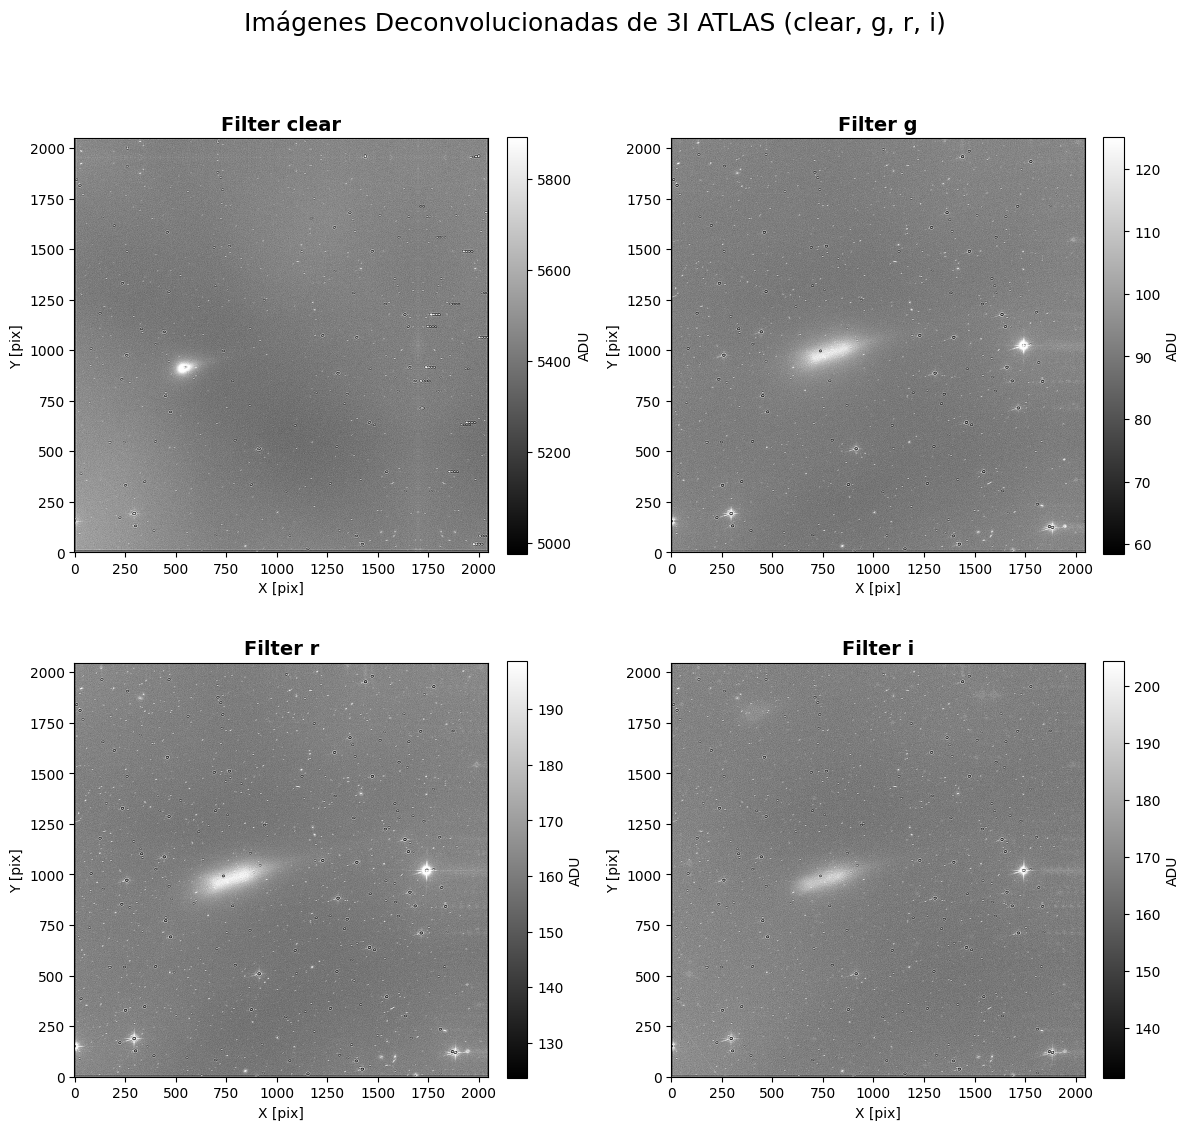

In [36]:
import os
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize


# Base route
#Procesando las imágenes de NGC 1365 para 3I/ATLAS, descomentar la otra línea, y viceversa
#object = "NGC_1365"
object = "3I_ATLAS"
base_path = f"../{object}/"
deconv_dir = os.path.join(base_path, "Camila/Deconvolved/")

files = {
    'clear': os.path.join(deconv_dir, f"deconv_{object.replace("_", "")}_clear.fits"),
    'g': os.path.join(deconv_dir, f"deconv_{object.replace("_", "")}_g.fits"),
    'r': os.path.join(deconv_dir, f"deconv_{object.replace("_", "")}_r.fits"),
    'i': os.path.join(deconv_dir, f"deconv_{object.replace("_", "")}_i.fits")
}

# Configuración del gráfico
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
filtros = ['clear', 'g', 'r', 'i']
axes_flat = axes.flatten()

print("Generando panel de imágenes...")

for idx, filt in enumerate(filtros):
    ax = axes_flat[idx]
    filepath = files[filt]
    
    if os.path.exists(filepath):
        try:
            # 1. Cargar datos
            data = fits.getdata(filepath).astype(float)
            
            # 2. Calcular normalización ZScale (Contraste automático astronómico)
            interval = ZScaleInterval()
            vmin, vmax = interval.get_limits(data)
            
            # 3. Graficar
            im = ax.imshow(data, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
            
            # Decoración
            ax.set_title(f"Filter {filt}", fontsize=14, fontweight='bold')
            ax.set_xlabel("X [pix]")
            ax.set_ylabel("Y [pix]")
            
            # Añadir barra de color pequeña
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='ADU')
            
        except Exception as e:
            print(f"Error al leer {filt}: {e}")
            ax.text(0.5, 0.5, f"Error\n{filt}", ha='center', va='center', color='red')
    else:
        ax.text(0.5, 0.5, f"Archivo no encontrado:\n{filt}", ha='center', va='center', color='red')
        print(f"No encontrado: {filepath}")

# Título general
plt.suptitle(f"Imágenes Deconvolucionadas de {object.replace("_", " ")} (clear, g, r, i)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para que no tape el título
plt.savefig(os.path.join(deconv_dir, f"{object.replace("_", "")}_Panel_Deconvolucionada.png"), dpi=300)
plt.show()
plt.close(fig)

### Creación de Figura AJUSTADA de Imágenes Finales (Stack + Alineamiento + Deconvolución)

Generando panel con rango dinámico ajustado...


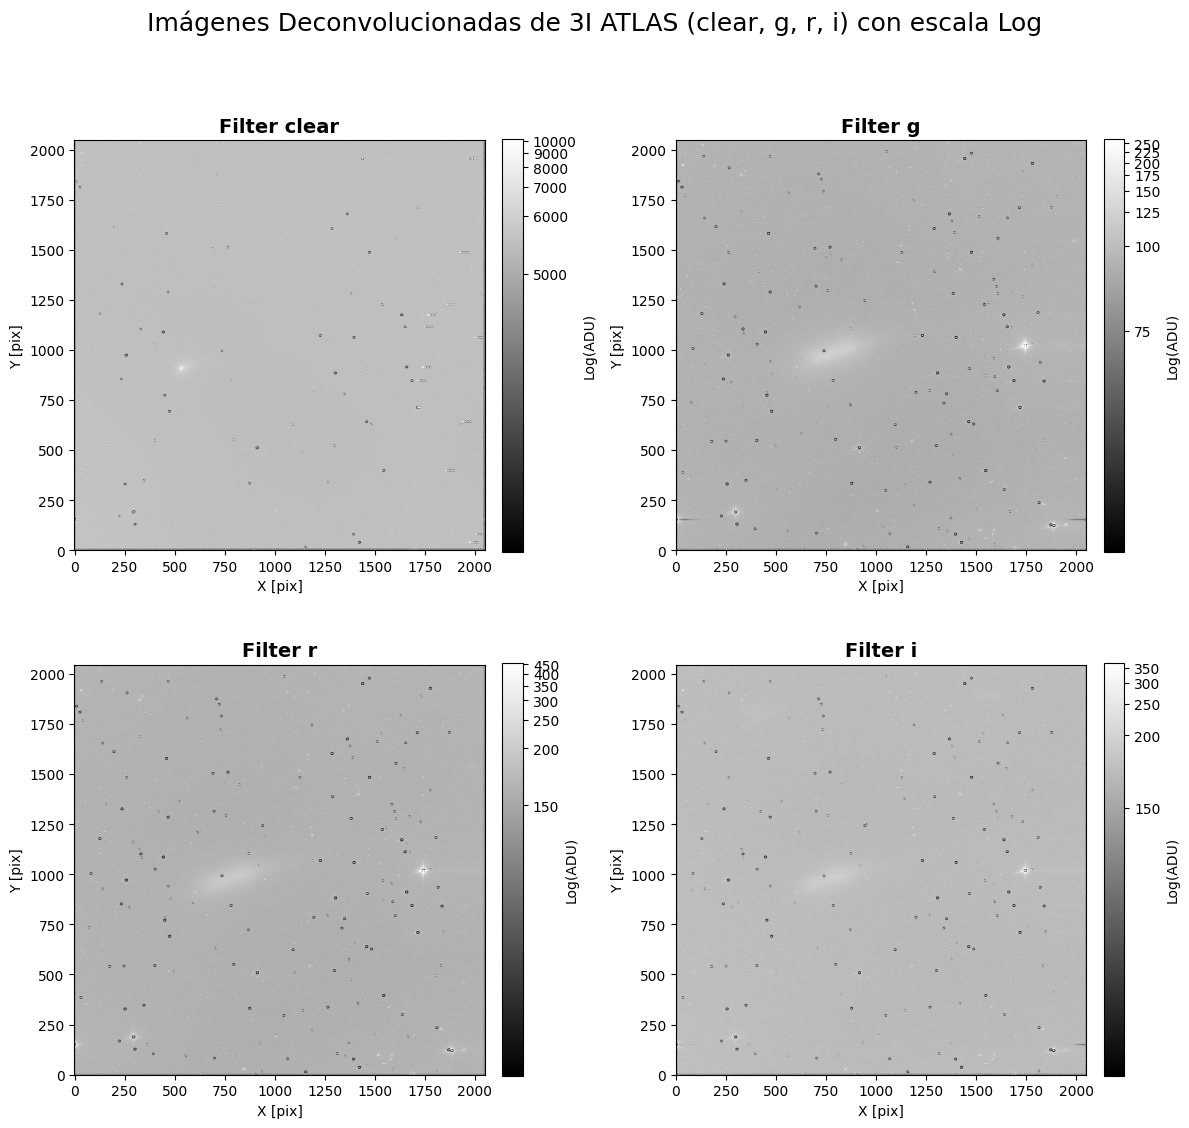

In [37]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import AsymmetricPercentileInterval, LogStretch, ImageNormalize

# Base route
#Procesando las imágenes de NGC 1365 para 3I/ATLAS, descomentar la otra línea, y viceversa
#object = "NGC_1365"
object = "3I_ATLAS"
base_path = f"../{object}/"
deconv_dir = os.path.join(base_path, "Camila/Deconvolved/")

files = {
    'clear': os.path.join(deconv_dir, f"deconv_{object.replace("_", "")}_clear.fits"),
    'g': os.path.join(deconv_dir, f"deconv_{object.replace("_", "")}_g.fits"),
    'r': os.path.join(deconv_dir, f"deconv_{object.replace("_", "")}_r.fits"),
    'i': os.path.join(deconv_dir, f"deconv_{object.replace("_", "")}_i.fits")
}

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
filtros = ['clear', 'g', 'r', 'i']
axes_flat = axes.flatten()

print("Generando panel con rango dinámico ajustado...")

for idx, filt in enumerate(filtros):
    ax = axes_flat[idx]
    filepath = files[filt]
    
    if os.path.exists(filepath):
        try:
            data = fits.getdata(filepath).astype(float)
            
            # --- AJUSTE CLAVE ---
            # En lugar de ZScale, usamos un intervalo basado en percentiles
            # lower_percentile=1: Elimina los negros puros (ruido de fondo)
            # upper_percentile=99.5: Sube el límite blanco para incluir el bulbo brillante
            
            # Opción A: Escala Lineal con percentiles más altos (Mejor control del blanco)
            # interval = AsymmetricPercentileInterval(1, 99.8) 
            # vmin, vmax = interval.get_limits(data)
            # norm = None
            
            # Opción B: Escala Logarítmica (La mejor para ver núcleo Y brazos)
            # LogStretch() comprime las luces altas para que el núcleo no sature tanto
            norm = ImageNormalize(data, interval=AsymmetricPercentileInterval(0.5, 99.9), stretch=LogStretch())
            
            # Graficar usando 'norm'
            im = ax.imshow(data, origin='lower', cmap='gist_gray', norm=norm)
            
            ax.set_title(f"Filter {filt}", fontsize=14, fontweight='bold')
            ax.set_xlabel("X [pix]")
            ax.set_ylabel("Y [pix]")
            
            # Barra de color
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Log(ADU)')
            
        except Exception as e:
            print(f"Error al leer {filt}: {e}")
            ax.text(0.5, 0.5, f"Error\n{filt}", ha='center', color='red')
    else:
        ax.text(0.5, 0.5, f"No encontrado:\n{filt}", ha='center', color='red')

# Título general
plt.suptitle(f"Imágenes Deconvolucionadas de {object.replace("_", " ")} (clear, g, r, i) con escala Log", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para que no tape el título
plt.savefig(os.path.join(deconv_dir, f"{object.replace("_", "")}_Panel_Deconvolucionada_Log.png"), dpi=300)
plt.show()
plt.close(fig)